# Stage I - structural MRI measurement differences of numerical variability

## Measurements

### Data Matrix Representation

For each measurement $m$ and region of interest (ROI) $r$, we obtain data from $n$ MCA repetitions across $m$ subject/visit pairs. These observations can be represented using the design matrix $\mathcal{M}_{m,r}$:

| MCA \ Subject/Visit | $sv_1$    | $sv_2$    | $\cdots$ | $sv_{m-1}$ | $sv_m$    | Anatomical $\rightarrow$ |
|----------------------|-----------|-----------|----------|------------|-----------|--------------------------|
| $rep_1$             | $x_{1,1}$ | $x_{1,2}$ | $\cdots$ | $x_{1,m-1}$| $x_{1,m}$ | $x_{1,:}$                |
| $rep_2$             | $x_{2,1}$ | $x_{2,2}$ | $\cdots$ | $x_{2,m-1}$| $x_{2,m}$ | $x_{2,:}$                |
| $\vdots$            | $\vdots$  | $\vdots$  | $\ddots$ | $\vdots$   | $\vdots$  | $\vdots$                 |
| $rep_{n-1}$         | $x_{n-1,1}$| $x_{n-1,2}$| $\cdots$| $x_{n-1,m-1}$| $x_{n-1,m}$| $x_{n-1,:}$          |
| $rep_n$             | $x_{n,1}$ | $x_{n,2}$ | $\cdots$ | $x_{n,m-1}$| $x_{n,m}$ | $x_{n,:}$                |
| Numerical $\downarrow$ | $x_{:,1}$ | $x_{:,2}$ | $\cdots$ | $x_{:,m-1}$| $x_{:,m}$ |                          |

Data matrix of size $n \times m$ with MCA repetitions as rows ($rep_1$ to $rep_n$) and subject/visit pairs as columns ($sv_1$ to $sv_m$). Each cell $x_{i,j}$ represents the measurement for subject/visit pair $j$ during MCA repetition $i$.

### Numerical Variability


Numerical variability quantifies the extent to which measurements for a given subject vary across MCA repetitions. For each subject/visit pair $j$, this variability is computed as:

$$\text{Var}_{\text{numerical}}^{(j)} = \frac{1}{n - 1} \sum_{i=1}^n \left(x_{i,j} - \bar{x}_{:,j}\right)^2, \quad \text{with } \bar{x}_{:,j} = \frac{1}{n} \sum_{i=1}^n x_{i,j}$$


The average numerical (intra-subject) variability across all subjects is:

$$\sigma^2_{num} = \frac{1}{m} \sum_{j=1}^m \text{Var}_{\text{numerical}}^{(j)}$$

### Anatomical Variability

#### General version

Anatomical variability quantifies differences between subjects within each MCA repetition. For each repetition $i$, it is computed as:

$$\text{Var}_{\text{anatomical}}^{(i)} = \frac{1}{m - 1} \sum_{j=1}^m \left(x_{i,j} - \bar{x}_{i,:}\right)^2, \quad \text{with } \bar{x}_{i,:} = \frac{1}{m} \sum_{j=1}^m x_{i,j}$$

The average anatomical (inter-subject) variability across all repetitions is:

$$\sigma^2_{anat} = \frac{1}{n} \sum_{i=1}^n \text{Var}_{\text{anatomical}}^{(i)}$$

#### IEEE referenced

One can also use IEEE obersvation instead of MCA repetitions. Anatomical variability is computed on IEEE value 

Here $\sigma^2_{anat}$ becomes

$$\sigma^2_{anat} = \text{Var}_{\text{anatomical}}^{(\text{IEEE})}$$

### Cohens'd coefficient

Let $X_1$ and $X_2$ represent two distinct populations with $|X_1|=N$, $|X_2|=M$. Cohen's d is defined as:
$$
d = \frac{\mu_1 - \mu_2}{\sigma_{\text{pooled}}},
$$
where $\mu_1$ and $\mu_2$ are the means of populations $X_1$ and $X_2$, respectively, and $\sigma_{\text{pooled}}$ is the pooled standard deviation given by:
$$
\sigma_{\text{pooled}} = \sqrt{\frac{(N-1)\sigma^{2}_{X_1} + (M-1)\sigma^{2}_{X_2}}{N + M - 2}}.
$$

### Anatomical vs Numerical Ratio

Let $\sigma_{anat}$ the anatomical variability and $\sigma_{num}$ the numerical variability.

$$r = \frac{\sigma_{num}}{\sigma_{anat}}$$

### Anatomical vs Numerical Ratio Pooled

Let $\sigma_{anat,pooled}$ the anatomical variability and $\sigma_{num,pooled}$ the numerical variability pooled between the HC and PD populations.

$$r = \frac{\sigma_{num,pooled}}{\sigma_{anat,pooled}}$$


### Anatomical vs Numerical Index

$$I = \frac{\sigma^2_{anat} - \sigma^2_{num}}{\sigma^2_{anat} + \sigma^2_{num}}$$

In [2]:
import pandas as pd
import os
import plotly.express as px
import numpy as np
from pathlib import Path
from IPython.display import Image

root_dir = Path(os.getcwd())
stats_dir = root_dir / "stats_QCed" / "sampled"
display(f"root directory: {root_dir.as_posix().split('VIP-python-client')[-1]}")
display(f"stats directory: {stats_dir.as_posix().split('VIP-python-client')[-1]}")

'root directory: /example/freesurfer-fuzzy/notebooks'

'stats directory: /example/freesurfer-fuzzy/notebooks/stats_QCed/sampled'

In [3]:
def print_figure(fig, filename):
    display(fig)
    fig.write_image(filename)
    display(Image(filename=filename))

In [4]:
cohort = pd.read_csv("../cohort_stat.csv")
subjects = cohort["PATNO_id"].unique()
hc_subjects = cohort[cohort.dx_group == "HC"]["PATNO_id"].unique()
pd_subjects = cohort[cohort.dx_group != "HC"]["PATNO_id"].unique()

In [5]:
def compute_numerical_variability_cortical_metric(metric, population):

    df = pd.read_parquet(f"{stats_dir}/{metric}.parquet")
    df = df[df["subjects"].isin(population)]
    Card = df.subjects.nunique()
    display(f"Number unique subjects in population: {Card}")
    numerical = (
        df.groupby(["subjects", "hemi"])
        .var()
        .reset_index()
        .drop(columns=["subjects"])
        .groupby("hemi")
        .mean()
        .reset_index()
    )
    numerical = numerical.melt(id_vars=["hemi"], var_name="ROI", value_name="variance")
    numerical["ROI"] = numerical["ROI"].str.replace(f"_{metric}", "", regex=False)
    return Card, numerical


def compute_anatomical_variability_cortical_metric(metric, population):

    df = pd.read_parquet(f"{stats_dir}/{metric}.parquet")
    df = df[df["subjects"].isin(population)]
    card = len(df.subjects.unique())
    display(f"Number unique subjects in population: {card}")

    # Group by numerical repetition
    df_lh = df[df["hemi"] == "lh"].reset_index(drop=True)
    df_rh = df[df["hemi"] == "rh"].reset_index(drop=True)
    df_lh["Rank"] = (
        df_lh.sort_values(by=["subjects"]).rank(method="dense")["subjects"].astype(int)
    )
    df_rh["Rank"] = (
        df_rh.sort_values(by=["subjects"]).rank(method="dense")["subjects"].astype(int)
    )
    df = pd.concat([df_lh, df_rh], axis=0)
    df["Rep"] = df["Rank"]
    df["Rep"] = (
        df.groupby(["Rank", "hemi"])
        .rank(method="first")["Rep"]
        .reset_index()["Rep"]
        .astype(int)
    )

    # Compute the average among MCA repetition of variances across subjects
    anatomical = (
        df.drop(columns=["subjects"])
        .groupby(["Rep", "hemi"])
        .var()
        .reset_index()
        .groupby("hemi")
        .mean()
        .drop(columns=["Rep", "Rank"])
        .reset_index()
    )

    anatomical = anatomical.melt(
        id_vars=["hemi"], var_name="ROI", value_name="variance"
    )
    anatomical["ROI"] = anatomical["ROI"].str.replace(f"_{metric}", "", regex=False)

    return card, anatomical

## Numerical vs Anatomical Ratio

In [6]:
def compute_pooled_variance(card_1, population_1, card_2, population_2):
    assert(population_1.ROI.nunique() == population_2.ROI.nunique())
    assert(set(population_1.ROI.unique()) == set(population_2.ROI.unique()))

    variance_pooled = population_1.copy()
    variance_pooled['variance'] = (
        (card_1 - 1) * population_1["variance"]
        + (card_2 - 1) * population_2["variance"]
    ) / (card_1 + card_2 - 2)
    return variance_pooled

def compute_numerical_anatomical_ratio(
    numerical, anatomical, filename=None
):
    assert(numerical.ROI.nunique() == anatomical.ROI.nunique())
    assert(set(numerical.ROI.unique()) == set(anatomical.ROI.unique()))

    r_na = numerical.copy()
    r_na["r^2"] = numerical["variance"] / anatomical["variance"]
    r_na["r"] = r_na["r^2"].apply(np.sqrt)
    if filename:
        r_na.to_csv(filename, index=False)
    return r_na

### Cortical Thickness 

#### Ratio

In [7]:
# numerical variability
card_numerical, var_numerical = compute_numerical_variability_cortical_metric("thickness", subjects)
# anatomical variability
card_anatomical, var_anatomical = compute_anatomical_variability_cortical_metric("thickness", subjects)
# compute the ratio
r_na = compute_numerical_anatomical_ratio(var_numerical, var_anatomical, filename="thickness_r_na.csv")
r_na

'Number unique subjects in population: 600'

'Number unique subjects in population: 600'

,hemi,ROI,variance,r^2,r
0,lh,G_and_S_frontomargin,1.936385e-03,0.076517,0.276616
1,rh,G_and_S_frontomargin,2.867278e-03,0.091452,0.302410
2,lh,G_and_S_occipital_inf,1.202936e-03,0.039313,0.198275
3,rh,G_and_S_occipital_inf,1.302960e-03,0.036926,0.192163
4,lh,G_and_S_paracentral,1.537355e-03,0.050277,0.224226
...,...,...,...,...,...
149,rh,MeanThickness,1.855253e-04,0.021219,0.145667
150,lh,BrainSegVolNotVent,2.810805e+07,0.002300,0.047958
151,rh,BrainSegVolNotVent,2.810805e+07,0.002300,0.047957
152,lh,eTIV,4.611279e+05,0.000016,0.003953


#### Ratio Pooled

In [8]:
# numerical variability
card_numerical_hc, var_numerical_hc = compute_numerical_variability_cortical_metric(
    "thickness", hc_subjects
)
card_anatomical_hc, var_anatomical_hc = compute_anatomical_variability_cortical_metric(
    "thickness", hc_subjects
)
# anatomical variability
card_numerical_pd, var_numerical_pd = compute_numerical_variability_cortical_metric(
    "thickness", pd_subjects
)
card_anatomical_pd, var_anatomical_pd = compute_anatomical_variability_cortical_metric(
    "thickness", pd_subjects
)
# compute the pooled variance
var_numerical_pooled = compute_pooled_variance(
    card_numerical_hc, var_numerical_hc, card_numerical_pd, var_numerical_pd
)
var_anatomical_pooled = compute_pooled_variance(
    card_anatomical_hc, var_anatomical_hc, card_anatomical_pd, var_anatomical_pd
)
# compute the ratio
r_na_pooled = compute_numerical_anatomical_ratio(
    var_numerical_pooled, var_anatomical_pooled, filename="thickness_r_na_pooled.csv"
)
r_na_pooled

'Number unique subjects in population: 202'

'Number unique subjects in population: 202'

'Number unique subjects in population: 398'

'Number unique subjects in population: 398'

,hemi,ROI,variance,r^2,r
0,lh,G_and_S_frontomargin,1.936253e-03,0.076417,0.276436
1,rh,G_and_S_frontomargin,2.866908e-03,0.091421,0.302360
2,lh,G_and_S_occipital_inf,1.203020e-03,0.039313,0.198276
3,rh,G_and_S_occipital_inf,1.303052e-03,0.036888,0.192064
4,lh,G_and_S_paracentral,1.537313e-03,0.050304,0.224286
...,...,...,...,...,...
149,rh,MeanThickness,1.856113e-04,0.021222,0.145678
150,lh,BrainSegVolNotVent,2.812016e+07,0.002375,0.048734
151,rh,BrainSegVolNotVent,2.812016e+07,0.002375,0.048734
152,lh,eTIV,4.614978e+05,0.000016,0.004017


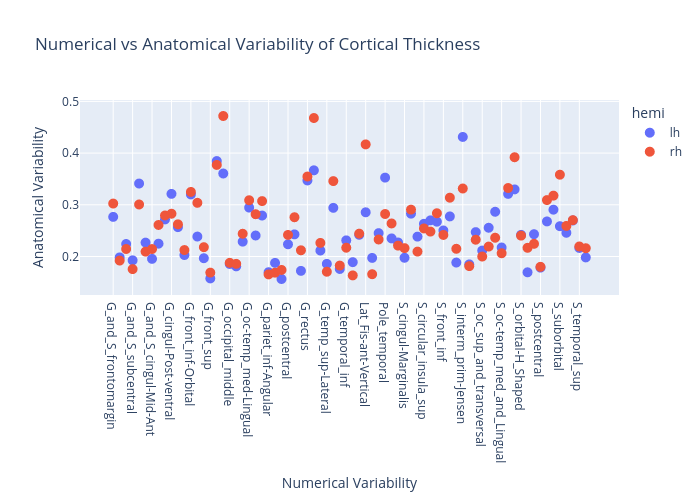

In [15]:
# filter out the ROIs eTIV and MeanThickness
r_na = r_na[~r_na.ROI.isin(["eTIV", "MeanThickness", "BrainSegVolNotVent"])]

fig = px.scatter(
    r_na,
    x="ROI",
    y="r",
    color="hemi",
    title="Numerical vs Anatomical Variability of Cortical Thickness",
).update_traces(marker=dict(size=10)).update_layout(
    xaxis_title="Numerical Variability", yaxis_title="Anatomical Variability"
)
print_figure(fig, "thickness_r_na.png")

#### Difference between pooled vs non-pooled

Max difference: 0.0025162838951004185


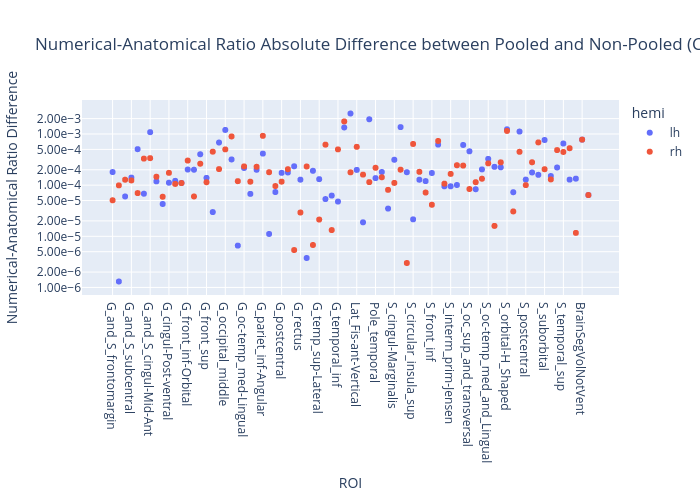

: 

In [ ]:
r_na_diff = r_na_pooled.copy()
r_na_diff["r"] = (r_na_diff["r"] - r_na["r"]).abs()
print(f"Max difference: {r_na_diff['r'].max()}")
fig = px.scatter(
    r_na_diff,
    x="ROI",
    y="r",
    log_y=True,
    color="hemi",
    title="Numerical-Anatomical Ratio Absolute Difference between Pooled and Non-Pooled (Cortical Thickness)",
    labels={"r": "Numerical-Anatomical Ratio Difference"},
).update_yaxes(tickformat=".2e")
print_figure(fig, "figures/thickness_r_na_diff.png")

### Surface Area

#### Ratio

In [ ]:
# numerical variability
card_numerical, var_numerical = compute_numerical_variability_cortical_metric("area", subjects)
# anatomical variability
card_anatomical, var_anatomical = compute_anatomical_variability_cortical_metric("area", subjects)
# compute the ratio
r_na = compute_numerical_anatomical_ratio(var_numerical, var_anatomical, filename="area_r_na.csv")
r_na

'Number unique subjects in population: 600'

'Number unique subjects in population: 600'

,hemi,ROI,variance,r^2,r_std,r
0,lh,G_and_S_frontomargin,1.180185e+03,0.077701,0.278750,0.278750
1,rh,G_and_S_frontomargin,1.098188e+03,0.113109,0.336316,0.336316
2,lh,G_and_S_occipital_inf,1.754355e+03,0.049294,0.222022,0.222022
3,rh,G_and_S_occipital_inf,1.207196e+03,0.049398,0.222258,0.222258
4,lh,G_and_S_paracentral,1.222032e+03,0.064173,0.253325,0.253325
...,...,...,...,...,...,...
149,rh,WhiteSurfArea,4.481779e+05,0.005945,0.077104,0.077104
150,lh,BrainSegVolNotVent,2.810805e+07,0.002300,0.047957,0.047957
151,rh,BrainSegVolNotVent,2.810805e+07,0.002300,0.047957,0.047957
152,lh,eTIV,4.611279e+05,0.000016,0.003953,0.003953


: 

#### Ratio Pooled

In [ ]:
# numerical variability
card_numerical_hc, var_numerical_hc = compute_numerical_variability_cortical_metric(
    "area", hc_subjects
)
card_anatomical_hc, var_anatomical_hc = compute_anatomical_variability_cortical_metric(
    "area", hc_subjects
)
# anatomical variability
card_numerical_pd, var_numerical_pd = compute_numerical_variability_cortical_metric(
    "area", pd_subjects
)
card_anatomical_pd, var_anatomical_pd = compute_anatomical_variability_cortical_metric(
    "area", pd_subjects
)
# compute the pooled variance
var_numerical_pooled = compute_pooled_variance(
    card_numerical_hc, var_numerical_hc, card_numerical_pd, var_numerical_pd
)
var_anatomical_pooled = compute_pooled_variance(
    card_anatomical_hc, var_anatomical_hc, card_anatomical_pd, var_anatomical_pd
)
# compute the ratio
r_na_pooled = compute_numerical_anatomical_ratio(
    var_numerical_pooled, var_anatomical_pooled, filename="area_r_na_pooled.csv"
)
r_na_pooled

'Number unique subjects in population: 202'

'Number unique subjects in population: 202'

'Number unique subjects in population: 398'

'Number unique subjects in population: 398'

,hemi,ROI,variance,r^2,r_std,r
0,lh,G_and_S_frontomargin,1.180150e+03,0.079858,0.282591,0.282591
1,rh,G_and_S_frontomargin,1.098202e+03,0.116123,0.340769,0.340769
2,lh,G_and_S_occipital_inf,1.754502e+03,0.049221,0.221857,0.221857
3,rh,G_and_S_occipital_inf,1.207316e+03,0.049623,0.222763,0.222763
4,lh,G_and_S_paracentral,1.222068e+03,0.064102,0.253185,0.253185
...,...,...,...,...,...,...
149,rh,WhiteSurfArea,4.483111e+05,0.006082,0.077988,0.077988
150,lh,BrainSegVolNotVent,2.812016e+07,0.002375,0.048734,0.048734
151,rh,BrainSegVolNotVent,2.812016e+07,0.002375,0.048734,0.048734
152,lh,eTIV,4.614978e+05,0.000016,0.004017,0.004017


: 

#### Difference between pooled vs non-pooled

Max difference: 0.00917764711079605


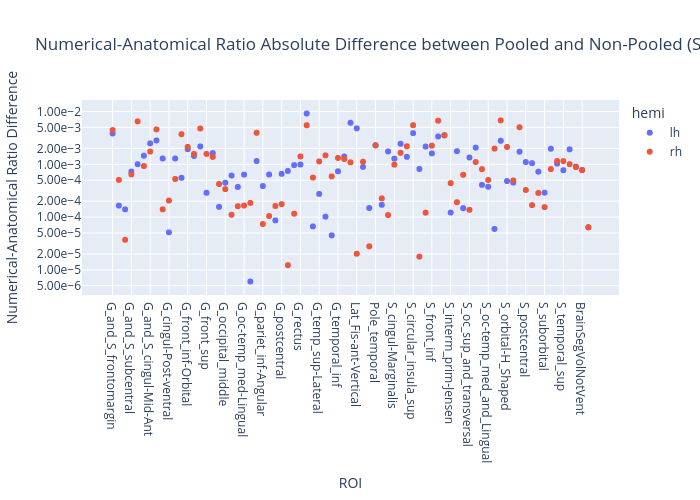

: 

In [ ]:
r_na_diff = r_na_pooled.copy()
r_na_diff["r"] = (r_na_diff["r"] - r_na["r"]).abs()
print(f"Max difference: {r_na_diff['r'].max()}")
fig = px.scatter(
    r_na_diff,
    x="ROI",
    y="r",
    log_y=True,
    color="hemi",
    title="Numerical-Anatomical Ratio Absolute Difference between Pooled and Non-Pooled (Surface Area)",
    labels={"r": "Numerical-Anatomical Ratio Difference"},
).update_yaxes(tickformat=".2e")
print_figure(fig, "figures/area_r_na_diff.png")

### Cortical Volume

#### Ratio

In [ ]:
# numerical variability
card_numerical, var_numerical = compute_numerical_variability_cortical_metric("volume", subjects)
# anatomical variability
card_anatomical, var_anatomical = compute_anatomical_variability_cortical_metric("volume", subjects)
# compute the ratio
r_na = compute_numerical_anatomical_ratio(var_numerical, var_anatomical, filename="volume_r_na.csv")
r_na

'Number unique subjects in population: 600'

'Number unique subjects in population: 600'

,hemi,ROI,variance,r^2,r_std,r
0,lh,G_and_S_frontomargin,1.110956e+04,0.103152,0.321172,0.321172
1,rh,G_and_S_frontomargin,1.056561e+04,0.130876,0.361768,0.361768
2,lh,G_and_S_occipital_inf,1.631181e+04,0.046527,0.215701,0.215701
3,rh,G_and_S_occipital_inf,1.091901e+04,0.036600,0.191311,0.191311
4,lh,G_and_S_paracentral,1.416934e+04,0.080681,0.284044,0.284044
...,...,...,...,...,...,...
147,rh,S_temporal_transverse,1.546536e+03,0.151732,0.389528,0.389528
148,lh,BrainSegVolNotVent,2.810805e+07,0.002300,0.047958,0.047958
149,rh,BrainSegVolNotVent,2.810805e+07,0.002300,0.047957,0.047957
150,lh,eTIV,4.611279e+05,0.000016,0.003953,0.003953


: 

#### Ratio Pooled

In [ ]:
# numerical variability
card_numerical_hc, var_numerical_hc = compute_numerical_variability_cortical_metric(
    "volume", hc_subjects
)
card_anatomical_hc, var_anatomical_hc = compute_anatomical_variability_cortical_metric(
    "volume", hc_subjects
)
# anatomical variability
card_numerical_pd, var_numerical_pd = compute_numerical_variability_cortical_metric(
    "volume", pd_subjects
)
card_anatomical_pd, var_anatomical_pd = compute_anatomical_variability_cortical_metric(
    "volume", pd_subjects
)
# compute the pooled variance
var_numerical_pooled = compute_pooled_variance(
    card_numerical_hc, var_numerical_hc, card_numerical_pd, var_numerical_pd
)
var_anatomical_pooled = compute_pooled_variance(
    card_anatomical_hc, var_anatomical_hc, card_anatomical_pd, var_anatomical_pd
)
# compute the ratio
r_na_pooled = compute_numerical_anatomical_ratio(
    var_numerical_pooled, var_anatomical_pooled, filename="volume_r_na_pooled.csv"
)
r_na_pooled

'Number unique subjects in population: 202'

'Number unique subjects in population: 202'

'Number unique subjects in population: 398'

'Number unique subjects in population: 398'

,hemi,ROI,variance,r^2,r_std,r
0,lh,G_and_S_frontomargin,1.110913e+04,0.104894,0.323873,0.323873
1,rh,G_and_S_frontomargin,1.056501e+04,0.133767,0.365742,0.365742
2,lh,G_and_S_occipital_inf,1.631226e+04,0.046466,0.215559,0.215559
3,rh,G_and_S_occipital_inf,1.091982e+04,0.036875,0.192028,0.192028
4,lh,G_and_S_paracentral,1.416913e+04,0.080721,0.284115,0.284115
...,...,...,...,...,...,...
147,rh,S_temporal_transverse,1.546554e+03,0.151902,0.389746,0.389746
148,lh,BrainSegVolNotVent,2.812016e+07,0.002375,0.048734,0.048734
149,rh,BrainSegVolNotVent,2.812016e+07,0.002375,0.048734,0.048734
150,lh,eTIV,4.614978e+05,0.000016,0.004017,0.004017


: 

#### Difference between pooled vs non-pooled

Max difference: 0.0070115339384744235


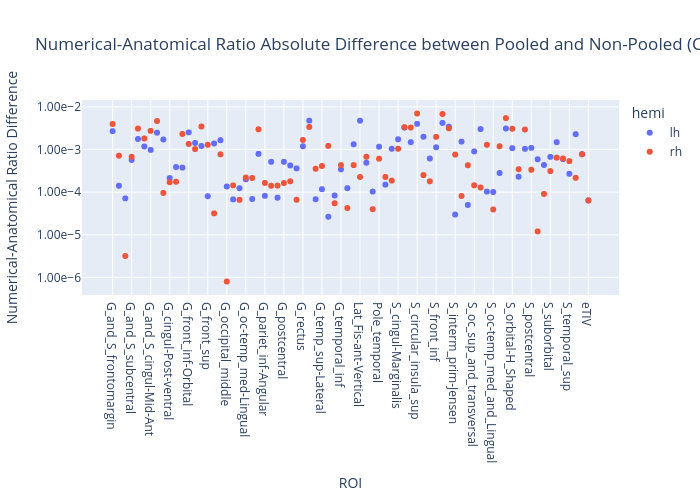

: 

In [ ]:
r_na_diff = r_na_pooled.copy()
r_na_diff["r"] = (r_na_diff["r"] - r_na["r"]).abs()
print(f"Max difference: {r_na_diff['r'].max()}")
fig = px.scatter(
    r_na_diff,
    x="ROI",
    y="r",
    log_y=True,
    color="hemi",
    title="Numerical-Anatomical Ratio Absolute Difference between Pooled and Non-Pooled (Cortical Volume)",
    labels={"r": "Numerical-Anatomical Ratio Difference"},
).update_yaxes(tickformat=".2e")
print_figure(fig, "figures/volume_r_na_diff.png")

### Subcortical Volume

In [ ]:
def compute_numerical_variability_subcortical_metric(metric, population):

    df = pd.read_parquet(f"{stats_dir}/{metric}.parquet")
    df = df[df["subjects"].isin(population)]
    Card = df.subjects.nunique()
    display(f"Number unique subjects in population: {Card}")
    numerical = (
        df.groupby(["subjects"])
        .var()
        .reset_index()
        .drop(columns=["subjects"])
        .mean()
        .reset_index()
    )
    numerical.rename(columns={"index": "ROI", 0:"variance"}, inplace=True)
    numerical["ROI"] = numerical["ROI"].str.replace(f"_{metric}", "", regex=False)
    return Card, numerical


def compute_anatomical_variability_subcortical_metric(metric, population):

    df = pd.read_parquet(f"{stats_dir}/{metric}.parquet")
    df = df[df["subjects"].isin(population)]
    card = len(df.subjects.unique())
    display(f"Number unique subjects in population: {card}")

    # Group by MCA repetition
    df["Rank"] = (
        df.sort_values(by=["subjects"])
        .rank(method="first")["subjects"]
        .astype(int)
        .reset_index(drop=True)
    )
    df["Rep"] = df["Rank"]
    df["Rep"] = (
        df.groupby("Rank")
        .rank(method="first")["Rep"]
        .astype(int)
    )

    # Compute the average among MCA repetition of variances across subjects
    anatomical = (
        df.drop(columns=["subjects","Rank"])
        .groupby(["Rep"])
        .var()
        .reset_index()
        .drop(columns=["Rep"])
        .mean()
        .reset_index()
    )
    anatomical.rename(columns={"index": "ROI", 0: "variance"}, inplace=True)
    anatomical["ROI"] = anatomical["ROI"].str.replace(f"_{metric}", "", regex=False)

    return card, anatomical

: 

#### Ratio

In [ ]:
# numerical variability
card_numerical, var_numerical = compute_numerical_variability_subcortical_metric(
    "subcortical_volume", subjects
)
# anatomical variability
card_anatomical, var_anatomical = compute_anatomical_variability_subcortical_metric(
    "subcortical_volume", subjects
)
# compute the ratio
r_na = compute_numerical_anatomical_ratio(
    var_numerical, var_anatomical, filename="thickness_r_na.csv"
)
r_na

'Number unique subjects in population: 600'

'Number unique subjects in population: 600'

,ROI,variance,r^2,r_std,r
0,Left-Lateral-Ventricle,9732.550601,0.000115,0.010728,0.010728
1,Left-Inf-Lat-Vent,1208.121442,0.007930,0.089050,0.089050
2,Left-Cerebellum-White-Matter,193125.265333,0.044826,0.211722,0.211722
3,Left-Cerebellum-Cortex,139076.759524,0.004365,0.066070,0.066070
4,Left-Thalamus,19876.859521,0.026490,0.162758,0.162758
...,...,...,...,...,...
59,MaskVol-to-eTIV,0.000003,0.001557,0.039454,0.039454
60,lhSurfaceHoles,66.177122,0.178211,0.422151,0.422151
61,rhSurfaceHoles,42.104411,0.150776,0.388299,0.388299
62,SurfaceHoles,120.269250,0.105416,0.324678,0.324678


: 

#### Ratio Pooled

In [ ]:
# numerical variability
card_numerical_hc, var_numerical_hc = compute_numerical_variability_subcortical_metric(
    "subcortical_volume", hc_subjects
)
card_anatomical_hc, var_anatomical_hc = compute_anatomical_variability_subcortical_metric(
    "subcortical_volume", hc_subjects
)
# anatomical variability
card_numerical_pd, var_numerical_pd = compute_numerical_variability_subcortical_metric(
    "subcortical_volume", pd_subjects
)
card_anatomical_pd, var_anatomical_pd = (
    compute_anatomical_variability_subcortical_metric("subcortical_volume", pd_subjects)
)
# compute the pooled variance
var_numerical_pooled = compute_pooled_variance(
    card_numerical_hc, var_numerical_hc, card_numerical_pd, var_numerical_pd
)
var_anatomical_pooled = compute_pooled_variance(
    card_anatomical_hc, var_anatomical_hc, card_anatomical_pd, var_anatomical_pd
)
# compute the ratio
r_na_pooled = compute_numerical_anatomical_ratio(
    var_numerical_pooled,
    var_anatomical_pooled,
    filename="subcortical_volume_r_na_pooled.csv",
)
r_na_pooled

'Number unique subjects in population: 202'

'Number unique subjects in population: 202'

'Number unique subjects in population: 398'

'Number unique subjects in population: 398'

,ROI,variance,r^2,r_std,r
0,Left-Lateral-Ventricle,9733.514027,0.000116,0.010783,0.010783
1,Left-Inf-Lat-Vent,1208.164789,0.008286,0.091026,0.091026
2,Left-Cerebellum-White-Matter,193158.875784,0.045850,0.214125,0.214125
3,Left-Cerebellum-Cortex,139109.630833,0.004498,0.067070,0.067070
4,Left-Thalamus,19879.904446,0.028061,0.167515,0.167515
...,...,...,...,...,...
59,MaskVol-to-eTIV,0.000003,0.001652,0.040641,0.040641
60,lhSurfaceHoles,66.165483,0.164566,0.405667,0.405667
61,rhSurfaceHoles,42.078886,0.114316,0.338107,0.338107
62,SurfaceHoles,120.225049,0.088278,0.297116,0.297116


: 

#### Difference between pooled vs non-pooled

Max difference: 0.007641019570298058


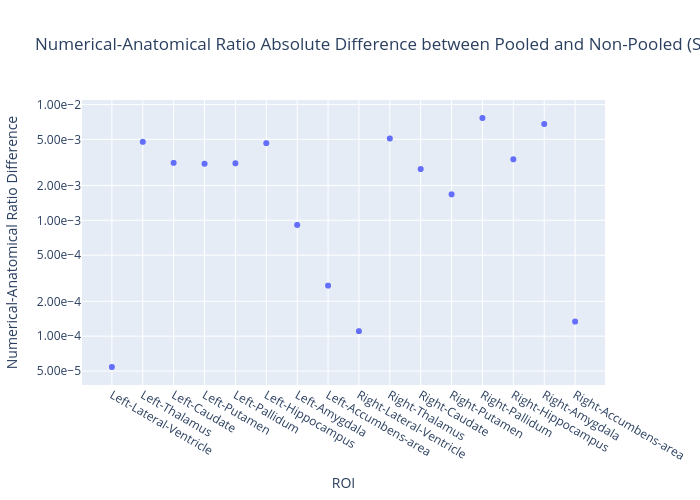

: 

In [ ]:
r_na_diff = r_na_pooled.copy()
r_na_diff["r"] = (r_na_diff["r"] - r_na["r"]).abs()
# Filter out ROI
roi_to_keep = [
        "Left-Accumbens-area",
        "Left-Amygdala",
        "Left-Caudate",
        "Left-Hippocampus",
        "Left-Pallidum",
        "Left-Putamen",
        "Left-Thalamus",
        "Left-Lateral-Ventricle",
        "Right-Accumbens-area",
        "Right-Amygdala",
        "Right-Caudate",
        "Right-Hippocampus",
        "Right-Pallidum",
        "Right-Putamen",
        "Right-Thalamus",
        "Right-Lateral-Ventricle",
    ]
r_na_diff = r_na_diff[r_na_diff.ROI.isin(roi_to_keep)]
print(f"Max difference: {r_na_diff['r'].max()}")
fig = px.scatter(
    r_na_diff,
    x="ROI",
    y="r",
    log_y=True,
    title="Numerical-Anatomical Ratio Absolute Difference between Pooled and Non-Pooled (Subcortical Volume)",
    labels={"r": "Numerical-Anatomical Ratio Difference"},
).update_yaxes(tickformat=".2e")
print_figure(fig, "figures/subcortical_volume_r_na_diff.png")